# Damage Curves under IPCC CO2 Scenarios -- Lao PDR

This notebook runs the combined frequency + damage model for Lao PDR under multiple IPCC CO2 concentration scenarios (SRES family: A1FI, A2, A1B, B2, B1), producing frequency projections, damage predictions, and damage curves for each scenario.

For reproducibility, inference data is cached in `idata/` and loaded if available. Figures are saved to `figures/`.

In [1]:
import sys
from pyprojroot import here

sys.path.insert(0, str(here()))

import pandas as pd
import numpy as np
import xarray as xr
import pickle
import pymc as pm
import pytensor.tensor as pt
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import arviz as az

import pandas_datareader.data as pdr
import datetime
from scipy import interpolate

import os
from os.path import exists
import pathlib
from cycler import cycler

from laos_gggi.model import add_data
from laos_gggi.plotting import configure_plot_style
from laos_gggi.data_functions import load_emdat_data, load_shapefile, load_rivers_data
from laos_gggi.replication_data import create_replication_data
from laos_gggi.statistics import standardize
from pymc.model.transform.optimization import freeze_dims_and_data

SCENARIOS = ['B1','B2', 'A1B', 'A1FI']
FIGURES_DIR = here('notebooks/policy_note/figures')
IDATA_DIR = here('notebooks/policy_note/idata')
PRETRAINED_IDATA_DIR = here('notebooks/final_paper/idata')

In [2]:
scenario_colors = {
    'A1FI': '#f94144',
    'A2': '#f3722c',
    'A1B': '#f9c74f',
    'B2': '#90be6d',
    'B1': '#208b3a',
}

OECD_colors = ["#002F6C", "#7FA8D9", "#006BB6", "#00AACC", "#82D2E3"]
OECD_cycler = cycler(color=OECD_colors)

config = {
    'figure.figsize': (14, 4),
    'figure.constrained_layout.use': True,
    'figure.facecolor': 'w',
    'axes.grid': False,
    'grid.linewidth': 0.5,
    'grid.linestyle': '--',
    'axes.spines.top': False,
    'axes.spines.bottom': False,
    'axes.spines.left': False,
    'axes.spines.right': False,
    'axes.prop_cycle': OECD_cycler,
}
plt.rcParams.update(config)

SEED = sum(list(map(ord, 'climate_bayes')))
rng = np.random.default_rng(SEED)

# Section 1: Load & Interpolate IPCC CO2 Scenarios

In [3]:
# Load IPCC projections (decadal data: 1970-2100)
ipcc_preds = pd.read_csv(here("data/ippc_projections.csv"), index_col="Year").head(14)
ipcc_preds.index = pd.to_datetime(ipcc_preds.index, format='%Y')

# Create full yearly date range and merge with decadal IPCC data
full_years = pd.date_range(start=ipcc_preds.index.min(), end=ipcc_preds.index.max(), freq='YS')
full_years_df = pd.DataFrame(index=full_years)
full_years_df.index.name = 'Year'

ipcc_preds_ext = full_years_df.join(ipcc_preds.astype(float))

# Linear interpolation to fill yearly gaps
ipcc_preds_interpolated = ipcc_preds_ext.interpolate(method='linear')

# Keep only our scenarios
ipcc_scenarios = ipcc_preds_interpolated[SCENARIOS]
ipcc_scenarios.head(10)

,B1,B2,A1B,A1FI
Year,,,,
1970-01-01,325.0,325.0,325.0,325.0
1971-01-01,326.2,326.2,326.2,326.2
1972-01-01,327.4,327.4,327.4,327.4
1973-01-01,328.6,328.6,328.6,328.6
1974-01-01,329.8,329.8,329.8,329.8
1975-01-01,331.0,331.0,331.0,331.0
1976-01-01,332.2,332.2,332.2,332.2
1977-01-01,333.4,333.4,333.4,333.4
1978-01-01,334.6,334.6,334.6,334.6


C:\Users\camil\AppData\Local\Temp\ipykernel_34460\4274030822.py:11: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


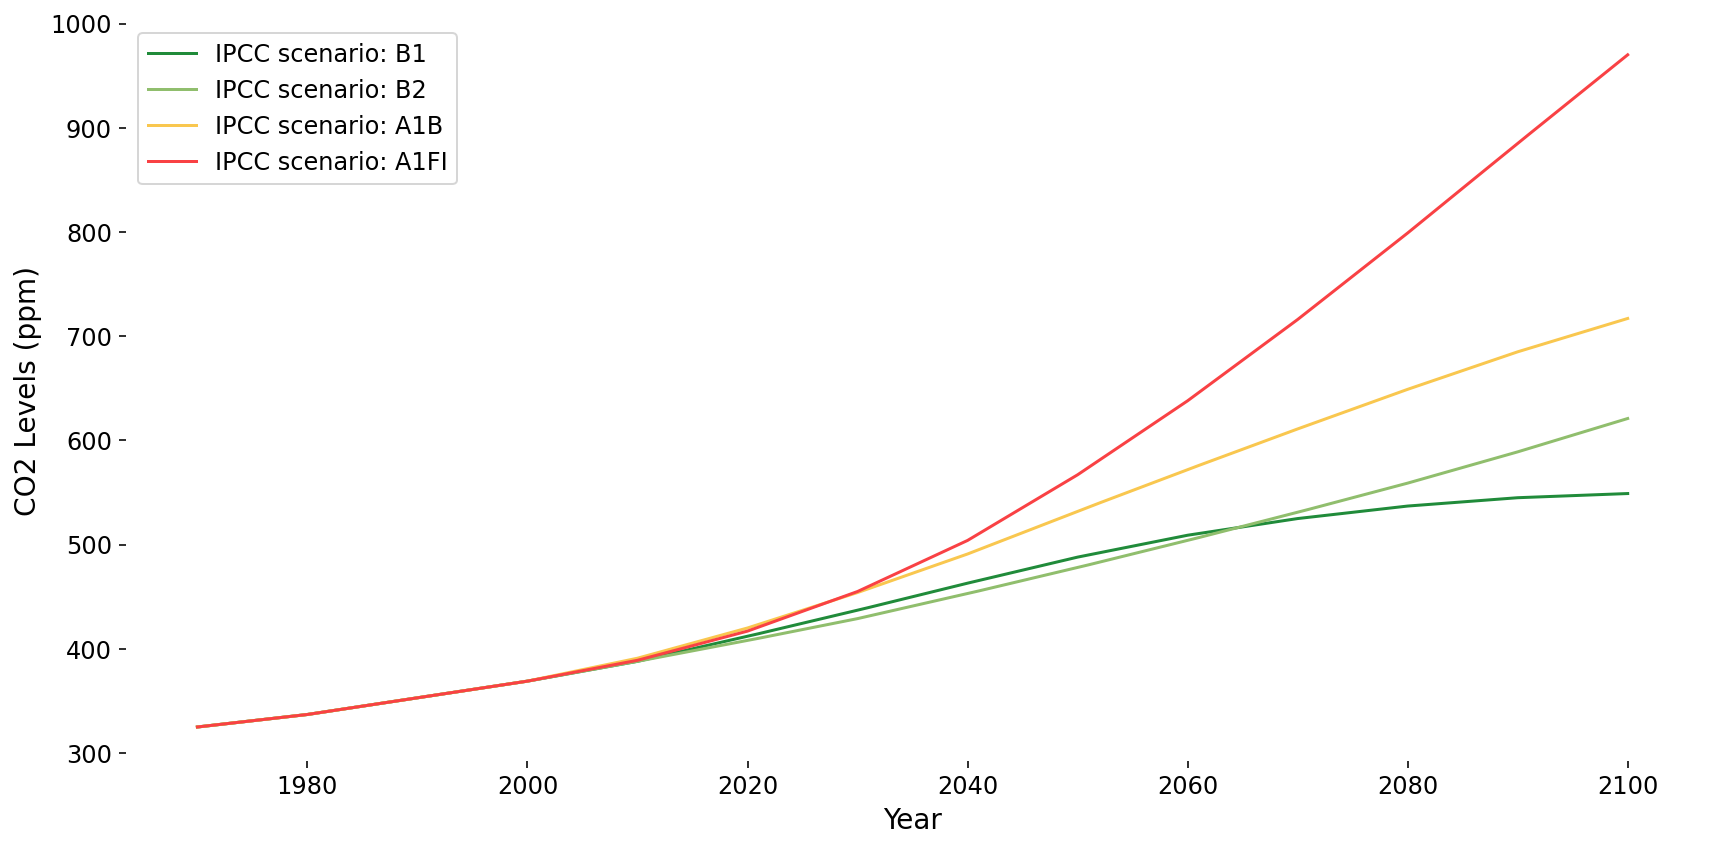

In [4]:
# Plot IPCC CO2 scenarios
fig, ax = plt.subplots(1, 1, figsize=(12, 6), dpi=144)
for scenario in SCENARIOS:
    sns.lineplot(x=ipcc_scenarios.index, y=ipcc_scenarios[scenario],
                 ax=ax, label=f"IPCC scenario: {scenario}",
                 color=scenario_colors[scenario])
ax.set_xlabel("Year", fontsize=14)
ax.set_ylabel("CO2 Levels (ppm)", fontsize=14)
ax.tick_params(axis='both', labelsize=12)
ax.legend(fontsize=12)
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'ipcc_scenarios_co2.png', format='png', bbox_inches='tight')
plt.show()

# Section 2: Data Loading & Preparation

In [5]:
# Select SEA countries
laos_neighboors = [
    "KHM",  # Cambodia
    "THA",  # Thailand
    "LAO",  # Laos
    "VNM",  # Vietnam
]

# Load replication data
df = (create_replication_data()
        .rename(columns={'ISO':'iso'})
        .set_index(["iso", "year"]))

# Load maps
world = load_shapefile('world')
sea_map = world.query('ISO_A3 in @laos_neighboors')
laos_map = world.query('ISO_A3 == "LAO"')

In [6]:
# Features and disasters
disasters = ["climatological_disasters", "hydrological_disasters"]
features = ["ln_population_density",
            "ln_gdp_pc",
            "square_ln_gdp_pc",
            "precip_deviation",
            "co2",
            "population"]

df.dropna(subset=features, inplace=True)

# Reconcile EMDAT and shapefile ISO codes
df_iso = df.index.get_level_values('iso').unique()
world_iso = world['ISO_A3'].unique()
world = world.assign(iso=world.ISO_A3)

common_codes = set(world_iso).intersection(set(df_iso))
df = df.query('iso in @common_codes').copy()
world = world.query('iso in @common_codes').copy()

# Get unique iso codes and years
code_idx, codes = pd.factorize(df.index.get_level_values("iso"), sort=True)
year_idx, years = pd.factorize(df.index.get_level_values("year"), sort=True)

y = df[disasters].copy().astype(float)
y_filled = y.fillna(0)

In [7]:
# Load EM-DAT damage data
emdat = load_emdat_data()

damage_events = (emdat['df_raw_filtered_adj']
           .loc[:, ['Start_Year', 'ISO', 'disaster_class', 'Total_Damage_Adjusted']]
           .dropna()
           .reset_index(drop=True)
           .rename(columns={'Start_Year':'year', 'ISO':'iso'}))

damage_events_full = (damage_events
     .groupby(['iso', 'year', 'disaster_class'])
     .apply(lambda x: x.assign(idx=np.arange(x.shape[0])),
            include_groups=False)
     .reset_index()
     .set_index(['iso', 'year', 'disaster_class', 'idx']))

_, codes_dmg = pd.factorize(damage_events_full.index.get_level_values(0), sort=True)
_, years_dmg = pd.factorize(damage_events_full.index.get_level_values(1), sort=True)
_, classes_dmg = pd.factorize(damage_events_full.index.get_level_values(2))

power_set = pd.MultiIndex.from_product([codes_dmg, years_dmg, classes_dmg, [0]],
                                        names=['iso', 'year', 'disaster_class', 'idx'])
total = pd.MultiIndex.from_tuples(set(power_set.values).union(set(damage_events_full.index)),
                                   names=['iso', 'year', 'disaster_class', 'idx'])

damage_events_full = damage_events_full.reindex(total).sort_index().drop(columns=['level_3'])
df_damage_full = (pd.merge(damage_events_full.reset_index(),
                     df[features].reset_index(),
                     left_on=['iso', 'year'],
                     right_on=['iso', 'year'])
             .sort_values(by=['disaster_class', 'iso', 'year'])
             .reset_index(drop=True))
df_damage_full['Total_Damage_Adjusted'] = df_damage_full['Total_Damage_Adjusted'] / 1e3

df_damage = (pd.merge(damage_events.reset_index(),
                     df[features].reset_index(),
                     left_on=['iso', 'year'],
                     right_on=['iso', 'year'])
             .sort_values(by=['disaster_class', 'iso', 'year'])
             .reset_index(drop=True))
df_damage['Total_Damage_Adjusted'] = df_damage['Total_Damage_Adjusted'] / 1e3

df_damage_full = df_damage_full.query('iso in @df_damage.iso').copy()

In [8]:
# Load forecast/prediction data (baseline -- CO2 will be replaced per scenario)
atmos_pred = pd.read_csv(here('data/CRIforecast.csv'))[['dev_ocean_temp', 'precip_deviation', 'co2', 'time']]
predictions = pd.read_csv(here('data/climate_forecast_lao.csv'))[['gdp_per_cap', 'Population', 'time']]
predictions['iso'] = 'LAO'

predictions = pd.merge(atmos_pred, predictions, on='time').rename(columns={"time": "Start_Year"})

predictions["population_density"] = predictions["Population"] / 236800 * 1e6
predictions = predictions.rename(columns={'Population': 'population',
                                           'dev_ocean_temp': 'dev_from_trend_ocean_temp'})
predictions['year'] = pd.to_datetime(predictions['Start_Year'])
predictions["ln_population_density"] = np.log(predictions["population_density"])
predictions["ln_gdp_pc"] = np.log(predictions["gdp_per_cap"])

# Save baseline predictions before scenario substitution
base_predictions = predictions.copy()

In [9]:
# Feature definitions
damage_features_base = ['ln_population_density', 'ln_gdp_pc',
       'precip_deviation', 'co2', 'population']

damage_features_base_d = ['d_' + x for x in damage_features_base]
damage_features_base_d_stand = [x + "__standardized" for x in damage_features_base_d]

for x, d_x in zip(damage_features_base, damage_features_base_d):
    df_damage[d_x] = df_damage[x]

damage_features_d_stand = ['ln_population_density__standardized',
 'ln_gdp_pc__standardized',
 'precip_deviation__standardized',
 'co2__standardized',
 'population__standardized',
 ]

features_events = ["ln_population_density", "ln_gdp_pc", "precip_deviation", "co2", "population"]
all_features = features_events + damage_features_d_stand

# Section 3: Helper Functions

In [10]:
def curves_model(coords, df,
                 codes_idx_joint,
                 features_events,
                 damage_features_d_stand,
                 class_idx_joint):

    with pm.Model(coords=coords) as model:
        ######################################## event model ########################################
        X_event = pm.Data('X', df[features_events])
        iso_idx_pt = pm.Data('iso_idx', codes_idx_joint, dims=['obs_idx'])

        latent_iso_events = pm.Flat('latent_iso_events', dims=['iso', 'features_events'])

        country_loc = pm.Flat('country_loc', dims=['disaster'])
        country_scale = pm.Flat('country_scale', dims=['disaster'])
        country_offset = pm.Flat('country_offset', dims=['iso', 'disaster'])

        country_effect = pm.Deterministic('country_effect',
                                          country_loc[None] + country_scale[None] * country_offset,
                                          dims=['iso', 'disaster'])

        beta = pm.Flat('beta', dims=['features_events', 'disaster'])
        beta_GY = pm.Flat('beta_GY', dims=['features_events', 'disaster'])
        coef_effect = X_event @ beta + (latent_iso_events @ beta_GY)[iso_idx_pt]
        mixture = pm.Flat("mixture", dims=["iso", 'disaster'])

        latent_rate = (country_effect + mixture)[iso_idx_pt] + coef_effect
        mu = pt.softplus(latent_rate)

        zero_prob = pm.Flat('zero_prob', dims=['disaster'])
        alpha = pm.Flat('alpha', dims=['disaster'])

        y_hat_n_events = pm.ZeroInflatedNegativeBinomial('y_hat_n_events',
                                                psi=zero_prob,
                                                mu=pt.clip(mu, 1e-6, 300),
                                                alpha=alpha,
                                                observed=np.zeros((df.shape[0], 2)),
                                                dims=['obs_idx', 'disaster'])

        ######################################## Damages model ########################################
        X_damage = pm.Data('X_damage', df[damage_features_d_stand],
                dims=['obs_idx', 'features_damages'])

        class_idx_pt = pm.Data('class_idx', class_idx_joint, dims=['obs_idx'])

        latent_iso_damage = pm.Flat('latent_iso_damage', dims=['iso', 'features_damages'])

        country_loc_damage = pm.Flat('country_loc_damage', dims=['disaster'])
        country_scale_damage = pm.Flat('country_scale_damage', dims=['disaster'])
        country_offset_damage = pm.Flat('country_offset_damage', dims=['iso', 'disaster'])
        country_effect_damage = pm.Deterministic('country_effect_damage',
                                                 country_loc_damage + country_scale_damage * country_offset_damage,
                                          dims=['iso', 'disaster'])

        beta_damage = pm.Flat('beta_damage', dims=['features_damages', 'disaster'])
        beta_GY_damage = pm.Flat('beta_GY_damage', dims=['features_damages', 'disaster'])
        coef_effect_damage = X_damage @ beta_damage + (latent_iso_damage @ beta_GY_damage)[iso_idx_pt]

        mixture_damage = pm.Flat("mixture_damage", dims=["iso", 'disaster'])

        mu = ((country_effect_damage + mixture_damage)[iso_idx_pt] + coef_effect_damage)

        sigma = pm.Flat('sigma', dims=['disaster'])

        mus = [mu[pt.eq(class_idx_pt, i), i] for i in range(len(classes))]
        mu_damage = pm.Deterministic('mu_damage', pt.concatenate(mus, axis=0), dims=['obs_idx'])

        p_zero_damage = pm.Flat('p_zero_damage', dims=['disaster'])
        y_hat_damages = pm.HurdleLogNormal('y_hat_damages',
                       mu=mu_damage,
                       sigma=sigma[class_idx_pt],
                       psi=(1 - p_zero_damage)[class_idx_pt],
                       observed=np.zeros((df.shape[0],)),
                       dims=['obs_idx'])

        #################################### Damage curves ####################################
        damages_curves = pm.Deterministic("damages_curves", y_hat_damages * y_hat_n_events[:, 1], dims=['obs_idx'])

    return model

In [11]:
def obtain_base_table(idata, curve_years, iso='LAO'):
    computed_ry_damage = {}
    curves_df = pd.DataFrame()

    for year in curve_years:
        damages = idata.posterior_predictive.damages_curves.sel(obs_iso=iso, obs_year=year).values.ravel()
        data = np.sort(damages)
        n = len(data)
        cdf_vals = np.linspace(1/n, 1, n)

        ppf_func = interpolate.interp1d(cdf_vals, data, bounds_error=False, fill_value=(data[0], data[-1]))

        def compute_ry_damage(ry):
            return ppf_func(1 - 1/ry)

        rys = np.repeat(100, 1000000) / np.linspace(0, 100, num=1000000)
        rys = np.append(rys, np.repeat(100, 10) / np.array([0.01, 0.1, 0.2, 0.5, 1, 2, 10, 25, 50, 75]))
        percentile = np.repeat(100, 1000010) / rys
        year_ = year.year
        computed_ry_damage[year_] = pd.DataFrame({'percentile_inv': percentile, f'{year_}': compute_ry_damage(rys)}).set_index('percentile_inv').T

        curves_df = pd.concat([curves_df, computed_ry_damage[year_].T], axis=1)

    curves_df = curves_df.reset_index()
    curves_df = curves_df.assign(percentile=lambda x: 100 - x["percentile_inv"]).set_index('percentile')
    curves_df = curves_df.sort_index(ascending=True)

    return curves_df, percentile


def build_return_years_curve(curves_df, percentile):
    return_years_table = curves_df.loc[np.repeat(100, 10) - percentile[-10:]].drop_duplicates()

    return_years_table = return_years_table.assign(value=lambda x: (100 / x['percentile_inv']).round(decimals=1))
    return_years_table = (return_years_table.assign(
        return_years=lambda x: x['value'].round(0).astype(int).astype(str) + ' RY')
                          .drop(columns=['value', 'percentile_inv']).set_index('return_years'))
    return return_years_table.tail(6)

# Section 4: Load Pre-trained Posteriors & Merge

In [12]:
# Load pre-trained model posteriors
damages_idata = az.from_netcdf(PRETRAINED_IDATA_DIR / 'dmg_5_2025_usd_new_b.nc')
events_idata = az.from_netcdf(PRETRAINED_IDATA_DIR / 'freq_model_4_1000d.nc')

# Rename to avoid conflicts when merging
events_idata = events_idata.rename({'latent_iso': 'latent_iso_events'})

damages_idata = damages_idata.rename({
    "country_loc": "country_loc_damage",
    'country_scale': 'country_scale_damage',
    'country_offset': 'country_offset_damage',
    'country_effect': 'country_effect_damage',
    'beta': 'beta_damage',
    'beta_GY': 'beta_GY_damage',
    'mixture': 'mixture_damage',
    'alpha_X': 'alpha_X_damage',
    'latent_iso': 'latent_iso_damage',
    'phi': 'phi_damage',
    'phi_climatological_disasters': 'phi_climatological_disasters_damage',
    'phi_hydrological_disasters': 'phi_hydrological_disasters_damage',
    'rho': 'rho_damage',
    'sigma_X': 'sigma_X_damage',
    'theta': 'theta_Damage',
    'p_zero': 'p_zero_damage',
    'mu': 'mu_damage',
})

# Merge posteriors
merged_posteriors_0 = xr.merge([
    damages_idata.posterior.drop_vars(['mu_damage']).drop_dims('obs_idx'),
    events_idata.posterior
])

print(f"Merged posteriors: {list(merged_posteriors_0.data_vars)[:10]}...")

Merged posteriors: ['alpha_X_damage', 'beta_damage', 'beta_GX', 'beta_GY_damage', 'country_effect_damage', 'country_loc_damage', 'country_offset_damage', 'country_scale_damage', 'latent_iso_damage', 'mixture_damage']...


In [13]:
# Damage class indices (needed for curves_model)
iso_idx, codes = pd.factorize(df_damage['iso'], sort=True)
year_idx, years = pd.factorize(df_damage['year'], sort=True)
class_idx, classes = pd.factorize(df_damage['disaster_class'].replace(
    {'Hydrometereological': 'hydro', 'Climatological': 'climate'}))
class_to_idx = {name: idx for idx, name in enumerate(classes)}

curve_years = [
    pd.to_datetime('2030-01-01 00:00:00'),
    pd.to_datetime('2040-01-01 00:00:00'),
    pd.to_datetime('2050-01-01 00:00:00'),
]

print(f"Classes: {list(classes)}")
print(f"Curve years: {[y.year for y in curve_years]}")

Classes: ['climate', 'hydro']
Curve years: [2030, 2040, 2050]


# Section 5: Run Pipeline per IPCC Scenario

For each scenario, we:
1. Replace the CO2 column in predictions with the IPCC interpolated values
2. Concatenate predictions onto the training data
3. Standardize features
4. Build the combined model
5. Sample posterior predictive (or load from cache)
6. Store results

In [14]:
scenario_results = {}

for scenario in SCENARIOS:
    print(f"\n{'='*60}")
    print(f"Processing scenario: {scenario}")
    print(f"{'='*60}")

    cache_file = IDATA_DIR / f'idata_scenario_{scenario}.pkl'

    if exists(cache_file):
        print(f"Loading cached idata for {scenario}...")
        with open(cache_file, 'rb') as f:
            idata_scenario = pickle.load(f)
        scenario_results[scenario] = idata_scenario
        continue

    # 1. Replace CO2 in predictions with IPCC scenario values
    scenario_predictions = base_predictions.copy()
    pred_years = scenario_predictions['year']
    # Get IPCC CO2 values for matching years
    ipcc_co2_lookup = ipcc_scenarios[scenario]
    for i, yr in enumerate(pred_years):
        if yr in ipcc_co2_lookup.index:
            scenario_predictions.loc[scenario_predictions.index[i], 'co2'] = ipcc_co2_lookup.loc[yr]

    # 2. Slice forecast period and concat with training data
    shorter_pred = scenario_predictions.set_index(['iso', 'year']).query('2020 < year < 2056')
    prediction_dates = shorter_pred.index.get_level_values(1).to_list()
    df_scenario = pd.concat([df.copy(), shorter_pred])

    # 3. Standardize features
    transformer_events_s, df_stand_s = standardize(df=df_scenario, columns=features_events)
    transformer_damages_s, df_damage_stand_s = standardize(df=df_damage, columns=features_events)

    df_joint_stand = pd.DataFrame(
        transformer_damages_s.transform(df_scenario[features_events]),
        columns=damage_features_d_stand,
        index=df_scenario.index
    )
    df_joint_stand = df_joint_stand.join(df_scenario).drop_duplicates()

    # 4. Build indices
    code_idx_s, codes_s = pd.factorize(df_scenario.reset_index()['iso'], sort=True)
    codes_to_idx_s = {name: idx for idx, name in enumerate(codes_s)}
    codes_idx_joint = df_joint_stand.reset_index()['iso'].map(codes_to_idx_s.get)

    df_joint_stand['disaster_class'] = 'hydro'
    class_idx_joint = df_joint_stand['disaster_class'].map(class_to_idx.get)

    year_idx_s, years_s = pd.factorize(df_scenario.index.get_level_values("year"), sort=True)

    coords_combined = {
        'iso': codes_s,
        'year': [dt.year for dt in years_s],
        'disaster': ['climate', 'hydro'],
        'obs_idx': np.arange(df_joint_stand.shape[0]),
        'features_events': features_events,
        'features_damages': damage_features_d_stand,
    }

    combined_xr_idx = xr.Coordinates.from_pandas_multiindex(
        df_joint_stand.reset_index().set_index(['iso', 'year', 'disaster_class'])
        .index.rename({'iso': 'obs_iso', 'year': 'obs_year', 'disaster_class': 'obs_disaster_class'}),
        'obs_idx'
    )

    # 5. Build model
    combined_model = curves_model(
        coords=coords_combined, df=df_joint_stand,
        codes_idx_joint=codes_idx_joint,
        features_events=features_events,
        damage_features_d_stand=damage_features_d_stand,
        class_idx_joint=class_idx_joint
    )

    # 6. Sample posterior predictive
    print(f"Sampling posterior predictive for {scenario}...")
    with freeze_dims_and_data(combined_model):
        idata_scenario = pm.sample_posterior_predictive(
            merged_posteriors_0, extend_inferencedata=False,
            compile_kwargs={'mode': 'JAX'},
            var_names=['damages_curves', 'y_hat_damages', 'y_hat_n_events']
        )

    idata_scenario = idata_scenario.assign_coords(combined_xr_idx)

    # 7. Cache
    with open(cache_file, 'wb') as f:
        pickle.dump(idata_scenario, f)

    scenario_results[scenario] = idata_scenario
    print(f"Done with {scenario}")

print(f"\nAll {len(SCENARIOS)} scenarios processed.")


Processing scenario: B1
Loading cached idata for B1...

Processing scenario: B2
Loading cached idata for B2...

Processing scenario: A1B
Loading cached idata for A1B...

Processing scenario: A1FI
Loading cached idata for A1FI...

All 4 scenarios processed.


# Section 6: Frequency Projections per Scenario

C:\Users\camil\AppData\Local\Temp\ipykernel_34460\3425555639.py:21: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


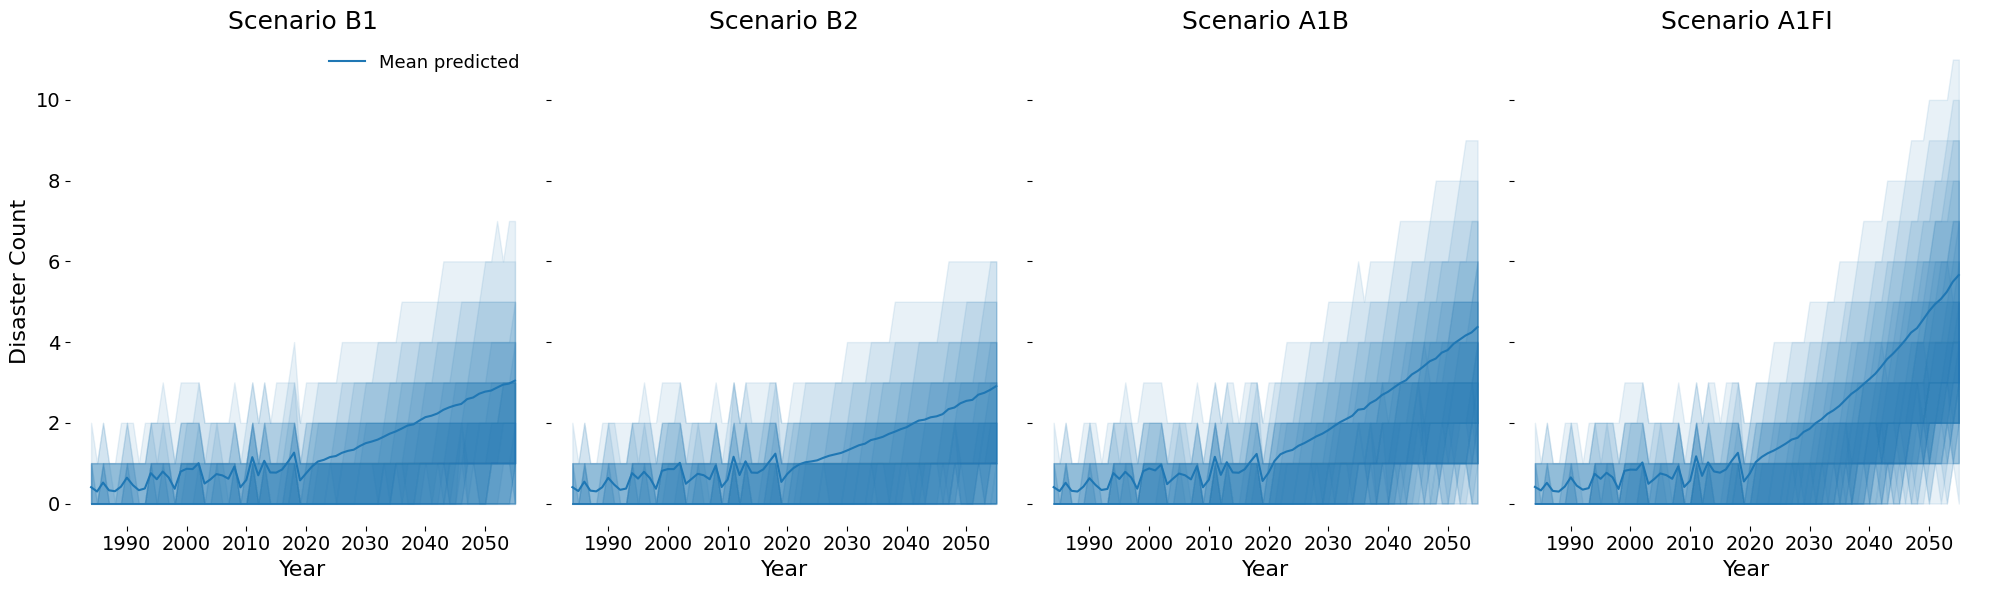

In [15]:
fig, axes = plt.subplots(1, len(SCENARIOS), figsize=(5 * len(SCENARIOS), 6), sharey=True)

for ax, scenario in zip(axes, SCENARIOS):
    idata = scenario_results[scenario]
    iso_idata = idata.posterior_predictive['y_hat_n_events'].sel(obs_iso='LAO')
    mu = iso_idata.mean(dim=['chain', 'draw'])
    index = mu['obs_year'].values

    ax.plot(index, mu.sel(disaster='hydro').values, color='tab:blue', label='Mean predicted')
    for hdi_prob in np.linspace(0.05, 0.95, 25)[::-1]:
        hdi = az.hdi(iso_idata.sel(disaster='hydro'), hdi_prob=hdi_prob)['y_hat_n_events']
        ax.fill_between(index, *hdi.values.T, color='tab:blue', alpha=0.1)

    ax.set_title(f'Scenario {scenario}', fontsize=18)
    ax.set_xlabel("Year", fontsize=16)
    ax.tick_params(axis='both', labelsize=14)
    if ax == axes[0]:
        ax.set_ylabel("Disaster Count", fontsize=16)
        ax.legend(fontsize=13, frameon=False)

plt.tight_layout()
fig.savefig(FIGURES_DIR / 'frequency_projections_scenarios.png', format='png', bbox_inches='tight', dpi=150)
plt.show()

# Section 7: Damage Projections per Scenario

C:\Users\camil\AppData\Local\Temp\ipykernel_34460\2677153514.py:30: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


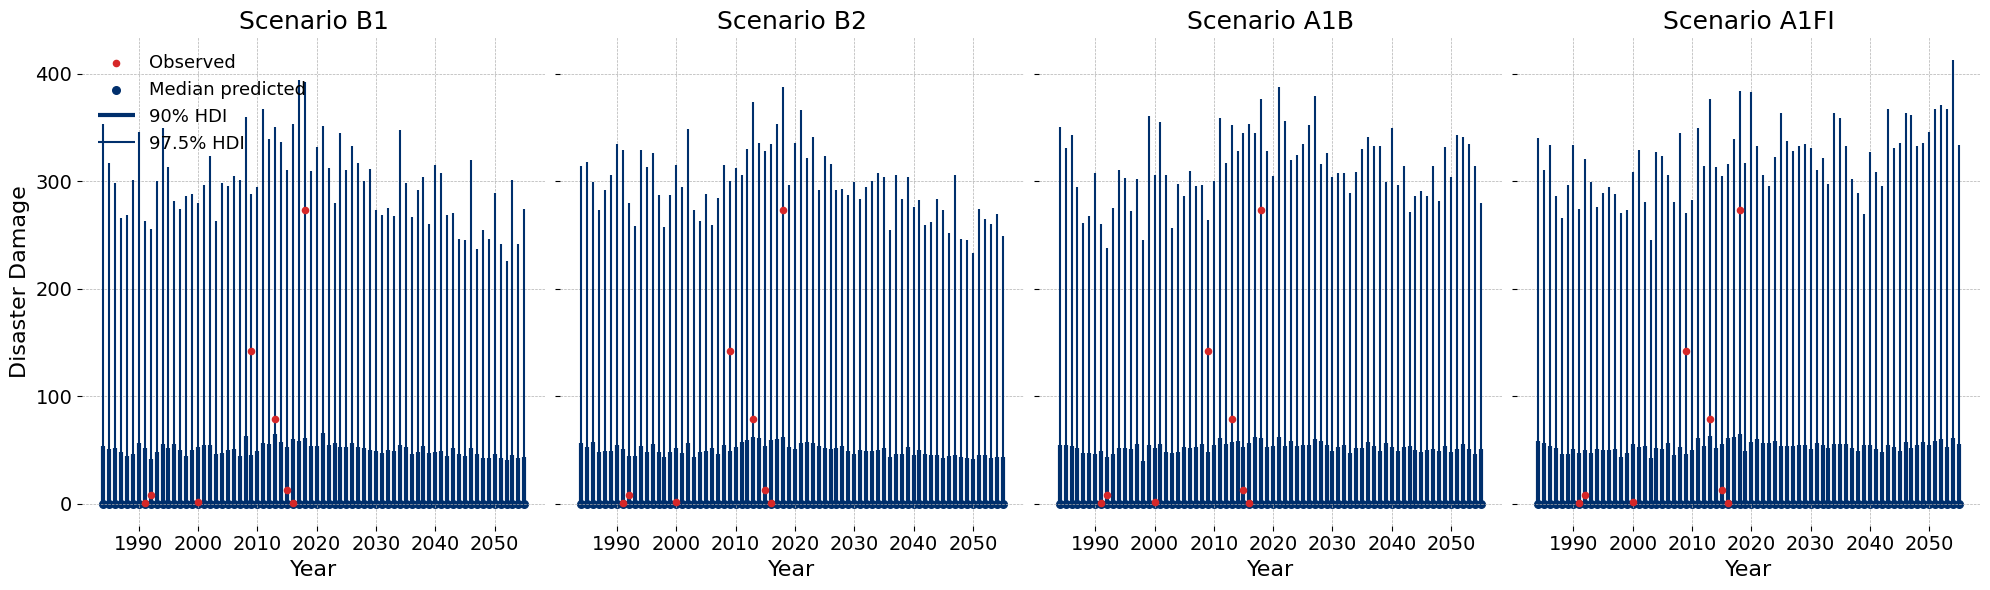

In [16]:
fig, axes = plt.subplots(1, len(SCENARIOS), figsize=(5 * len(SCENARIOS), 6), sharey=True)

# Observed damages (same across scenarios)
targets = (df_damage.replace('Hydrometereological', 'hydro')
           .query('iso == "LAO" & disaster_class == "hydro"')
           .groupby('year')['Total_Damage_Adjusted'].mean().resample('YS').last())

for ax, scenario in zip(axes, SCENARIOS):
    idata = scenario_results[scenario]
    data = idata.posterior_predictive.y_hat_damages.sel(
        obs_iso='LAO', obs_disaster_class='hydro').groupby('obs_year').mean()

    mu = data.quantile(0.5, dim=['chain', 'draw']).to_dataframe()['y_hat_damages'].resample('YS').last()
    hdi_90 = az.hdi(data, hdi_prob=0.90).y_hat_damages.to_dataframe()['y_hat_damages'].unstack('hdi').resample('YS').last()
    hdi_975 = az.hdi(data, hdi_prob=0.975).y_hat_damages.to_dataframe()['y_hat_damages'].unstack('hdi').resample('YS').last()

    ax.scatter(targets.index, targets.values, color='tab:red', zorder=100, s=20, label='Observed')
    ax.scatter(mu.index, mu.values, s=30, label='Median predicted')
    ax.vlines(mu.index, *hdi_90.values.T, lw=3, label='90% HDI')
    ax.vlines(mu.index, *hdi_975.values.T, label='97.5% HDI')
    ax.grid(ls='--', lw=0.5)

    ax.set_title(f'Scenario {scenario}', fontsize=18)
    ax.set_xlabel("Year", fontsize=16)
    ax.tick_params(axis='both', labelsize=14)
    if ax == axes[0]:
        ax.set_ylabel("Disaster Damage", fontsize=16)
        ax.legend(fontsize=13, loc='upper left', frameon=False)

plt.tight_layout()
fig.savefig(FIGURES_DIR / 'damage_projections_scenarios.png', format='png', bbox_inches='tight', dpi=150)
plt.show()

# Section 8: Damage Curves per Scenario

In [17]:
# Compute damage curves for each scenario
scenario_curves = {}
scenario_percentiles = {}

for scenario in SCENARIOS:
    print(f"Computing damage curves for {scenario}...")
    idata = scenario_results[scenario]
    curves_df, percentile = obtain_base_table(idata, curve_years, iso='LAO')
    scenario_curves[scenario] = curves_df
    scenario_percentiles[scenario] = percentile

print("Done.")

Computing damage curves for B1...


C:\Users\camil\AppData\Local\Temp\ipykernel_34460\243223103.py:16: RuntimeWarning: divide by zero encountered in divide
  rys = np.repeat(100, 1000000) / np.linspace(0, 100, num=1000000)
C:\Users\camil\AppData\Local\Temp\ipykernel_34460\243223103.py:16: RuntimeWarning: divide by zero encountered in divide
  rys = np.repeat(100, 1000000) / np.linspace(0, 100, num=1000000)
C:\Users\camil\AppData\Local\Temp\ipykernel_34460\243223103.py:16: RuntimeWarning: divide by zero encountered in divide
  rys = np.repeat(100, 1000000) / np.linspace(0, 100, num=1000000)


Computing damage curves for B2...


C:\Users\camil\AppData\Local\Temp\ipykernel_34460\243223103.py:16: RuntimeWarning: divide by zero encountered in divide
  rys = np.repeat(100, 1000000) / np.linspace(0, 100, num=1000000)
C:\Users\camil\AppData\Local\Temp\ipykernel_34460\243223103.py:16: RuntimeWarning: divide by zero encountered in divide
  rys = np.repeat(100, 1000000) / np.linspace(0, 100, num=1000000)
C:\Users\camil\AppData\Local\Temp\ipykernel_34460\243223103.py:16: RuntimeWarning: divide by zero encountered in divide
  rys = np.repeat(100, 1000000) / np.linspace(0, 100, num=1000000)


Computing damage curves for A1B...


C:\Users\camil\AppData\Local\Temp\ipykernel_34460\243223103.py:16: RuntimeWarning: divide by zero encountered in divide
  rys = np.repeat(100, 1000000) / np.linspace(0, 100, num=1000000)
C:\Users\camil\AppData\Local\Temp\ipykernel_34460\243223103.py:16: RuntimeWarning: divide by zero encountered in divide
  rys = np.repeat(100, 1000000) / np.linspace(0, 100, num=1000000)
C:\Users\camil\AppData\Local\Temp\ipykernel_34460\243223103.py:16: RuntimeWarning: divide by zero encountered in divide
  rys = np.repeat(100, 1000000) / np.linspace(0, 100, num=1000000)


Computing damage curves for A1FI...


C:\Users\camil\AppData\Local\Temp\ipykernel_34460\243223103.py:16: RuntimeWarning: divide by zero encountered in divide
  rys = np.repeat(100, 1000000) / np.linspace(0, 100, num=1000000)
C:\Users\camil\AppData\Local\Temp\ipykernel_34460\243223103.py:16: RuntimeWarning: divide by zero encountered in divide
  rys = np.repeat(100, 1000000) / np.linspace(0, 100, num=1000000)
C:\Users\camil\AppData\Local\Temp\ipykernel_34460\243223103.py:16: RuntimeWarning: divide by zero encountered in divide
  rys = np.repeat(100, 1000000) / np.linspace(0, 100, num=1000000)


Done.


In [18]:
# Return years table: MultiIndex columns (year x scenario)
scenario_return_years = {}

for scenario in SCENARIOS:
    curves_df = scenario_curves[scenario]
    percentile = scenario_percentiles[scenario]
    ry_table = build_return_years_curve(curves_df, percentile)
    scenario_return_years[scenario] = ry_table

# Build combined table with MultiIndex columns: (year, scenario)
combined = pd.concat(
    {scenario: ry_table[[str(y.year) for y in curve_years]]
     for scenario, ry_table in scenario_return_years.items()},
    axis=1
).swaplevel(axis=1).sort_index(axis=1, level=0, sort_remaining=False)

# Reorder columns: years as top level, scenarios as sub-level
year_order = [str(y.year) for y in curve_years]
combined = combined.reindex(columns=year_order, level=0)
combined.round(2).to_csv('data/return_years.csv')
display(combined.round(2))

2030                                2040                    \
                   B1       B2      A1B     A1FI       B1       B2      A1B   
return_years                                                                  
100 RY        1021.26  1089.99  1250.46  1409.52  1589.79  1383.46  2283.54   
50 RY          482.55   509.43   616.82   688.11   686.37   624.35  1028.00   
10 RY           52.19    43.99    75.21    74.96    81.83    69.00   121.84   
4 RY             4.53     3.53     8.24     8.20     8.96     7.94    16.13   
2 RY             0.00     0.00     0.00     0.00     0.00     0.00     0.00   
1 RY             0.00     0.00     0.00     0.00     0.00     0.00     0.00   

                          2050                             
                 A1FI       B1       B2      A1B     A1FI  
return_years                                               
100 RY        2313.93  1961.16  1699.21  2833.41  4326.76  
50 RY         1103.04   996.37   764.11  1440.66  1927.55  
10 RY          144.81   110.38    88.08   160.42   235.80  
4 RY            17.18    13.54    11.20    23.08    30.40  
2 RY             0.00     0.00     0.00     0.00     0.00  
1 RY             0.00     0.00     0.00     0.00     0.00

C:\Users\camil\AppData\Local\Temp\ipykernel_34460\1546506930.py:23: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


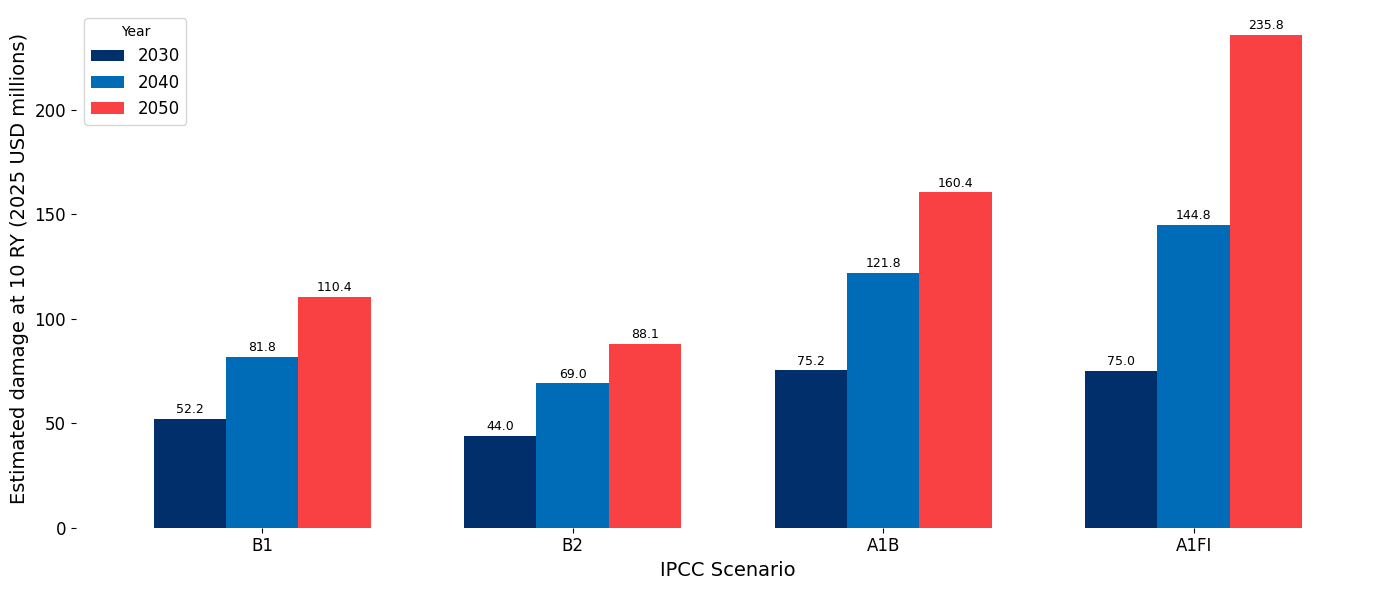

C:\Users\camil\AppData\Local\Temp\ipykernel_34460\1546506930.py:23: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


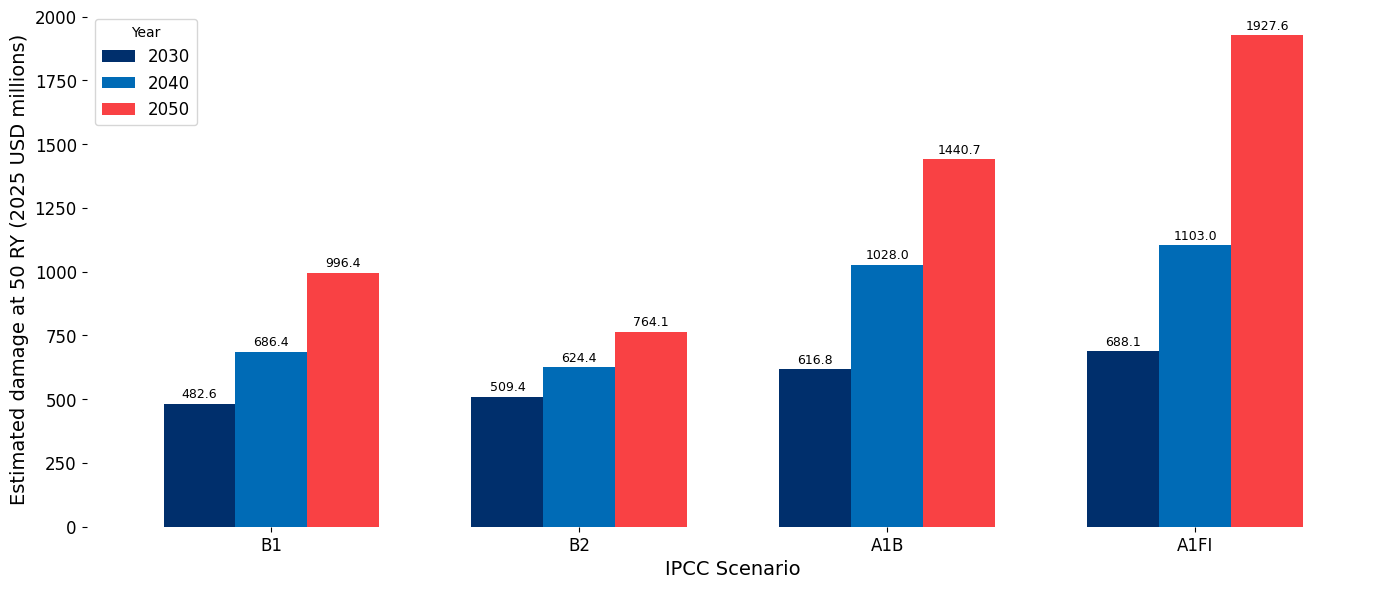

C:\Users\camil\AppData\Local\Temp\ipykernel_34460\1546506930.py:23: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


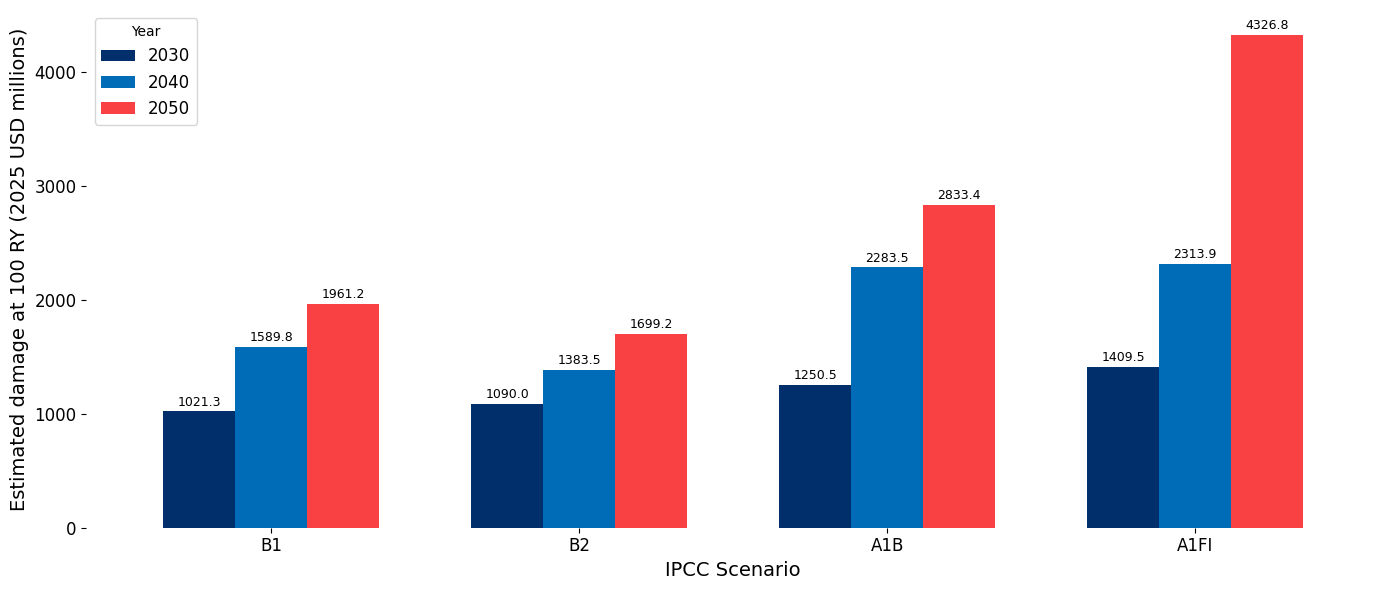

In [19]:
# Comparative bar plots: 10-RY, 50-RY, and 100-RY damage across scenarios and years
comparison_rys = ['10 RY', '50 RY', '100 RY']
curve_year_colors = ['#002F6C', '#006BB6', '#f94144']

for ry in comparison_rys:
    comparison_data = pd.DataFrame({
        scenario: scenario_return_years[scenario].loc[ry]
        for scenario in SCENARIOS
    }).T
    comparison_data.columns = [str(y.year) for y in curve_years]

    fig, ax = plt.subplots(figsize=(14, 6))
    comparison_data.plot(kind='bar', ax=ax, color=curve_year_colors[:len(curve_years)], width=0.7)
    ax.set_ylabel(f'Estimated damage at {ry} (2025 USD millions)', fontsize=14)
    ax.set_xlabel('IPCC Scenario', fontsize=14)
    ax.tick_params(axis='both', labelsize=12)
    ax.legend(fontsize=12, title='Year')
    plt.xticks(rotation=0)

    for container in ax.containers:
        ax.bar_label(container, fmt='%.1f', fontsize=9, padding=2)

    plt.tight_layout()
    fig.savefig(FIGURES_DIR / f'return_year_comparison_scenarios_{ry.replace(" ", "_").lower()}.png',
                format='png', bbox_inches='tight', dpi=150)
    plt.show()